In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from itertools import product

In [2]:
def comm(A,B):
    return A@B-B@A

def antisym_3_bra(X):
    assert X.shape == (2*P,2*P,2*P,2*P,2*P,2*P)
    return 1/6*( X 
              -np.einsum('abcijk->abcikj',X) 
              -np.einsum('abcijk->abcjik',X) 
              +np.einsum('abcijk->abcjki',X) 
              +np.einsum('abcijk->abckij',X) 
              -np.einsum('abcijk->abckji',X)  )

def antisym_3_ket(X):
    return 1/6*( X 
                -np.einsum('abcijk->acbijk',X) 
                -np.einsum('abcijk->bacijk',X) 
                +np.einsum('abcijk->bcaijk',X) 
                +np.einsum('abcijk->cabijk',X) 
                -np.einsum('abcijk->cbaijk',X) )

def antisym_3_full(X):
    return antisym_3_ket(antisym_3_bra(X))   # bra then ket (order doesn't matter, they commute)

def h0():
    h0 = np.zeros((2*P,2*P),dtype=complex)
    for i in range(-P,P):
        if i==0:
            h0[i+P,i+P] = eps/2 * 1
        else:
            h0[i+P,i+P] = eps/2 * np.sign(i)
    return h0

def v():
    v = np.zeros((2*P,2*P,2*P,2*P),dtype=complex)
    for i in range(-P,P):
        for j in range(-P,P):
            if (i >= 0) == (j >= 0): # only when i and j are both the same sign, eg if false == false and if true == true
                v[i+P, j+P, -i-1+P, -j-1+P] = -V/2
    v = v.reshape(4*P**2,4*P**2)
    return v
    
def TDHF(t,y):
    rho = y.reshape(2*P,2*P)
    d_rho = np.zeros_like(rho,dtype=complex)

    h0 = np.zeros((2*P,2*P),dtype=complex)
    for i in range(-P,P):
        if i==0:
            h0[i+P,i+P] = eps/2 * 1 # this is positive but sign(0)=0 
        else:
            h0[i+P,i+P] = eps/2 * np.sign(i)
    
    v = np.zeros((2*P,2*P,2*P,2*P),dtype=complex)
    for i in range(-P,P):
        for j in range(-P,P):
            if (i >= 0) == (j >= 0): # only when i and j are both the same sign, eg if false == false and if true == true
                v[i+P, j+P, -i-1 +P, -j-1 +P] = -V/2
    v = v.reshape(4*P**2,4*P**2)

    d_rho += comm(h0,rho)
    
    rhorho = np.kron(rho,rho).reshape(2*P,2*P,2*P,2*P) # axis 0,2 is particle 1, axis 1,3 is particle 2. 
    # now make the antisymmetrised 2body density
    arho12 = rhorho - np.einsum('ijkl->ijlk',rhorho) # swap second axis of the two particles ie axes 2 and 3
    arho12 = arho12.reshape(4*P**2,4*P**2)
    comm2 = comm(v,arho12)
    tr2 = np.trace(comm2.reshape(2*P,2*P,2*P,2*P), axis1=1, axis2=3)
    d_rho += tr2

    d_rho = -1j*d_rho
    return d_rho.ravel()


# """
# XXX FROM HERE 
# """
# def rho3_uncorrelated(rho):
#     """
#     A_(3) S_(3) [rho(1) rho(2) rho(3)].

#     Output indices:
#         out[i,j,k,l,m,n] = rho3(ijk,lmn)

#     This is the determinant-like three-body density, with exactly
#     six distinct terms and no normalization prefactor.
#     """
#     return (
#         + np.einsum('il,jm,kn->ijklmn', rho, rho, rho)
#         - np.einsum('il,jn,km->ijklmn', rho, rho, rho)
#         - np.einsum('im,jl,kn->ijklmn', rho, rho, rho)
#         + np.einsum('im,jn,kl->ijklmn', rho, rho, rho)
#         + np.einsum('in,jl,km->ijklmn', rho, rho, rho)
#         - np.einsum('in,jm,kl->ijklmn', rho, rho, rho)
#     )
# def rho_c2_unique(rho, c2):
#     """
#     A_(3) S_(3) [rho c2], with the nine distinct terms of
#     Eq. (2.11) in the paper.

#     rho[i,l]       = rho(i,l)
#     c2[i,j,l,m]    = c2(ij,lm)

#     Output:
#         out[i,j,k,l,m,n] = out(ijk,lmn)
#     """
#     return (
#         # Three direct cluster placements
#         + np.einsum('il,jkmn->ijklmn', rho, c2)  # rho(1) c2(23)
#         + np.einsum('jm,ikln->ijklmn', rho, c2)  # rho(2) c2(13)
#         + np.einsum('kn,ijlm->ijklmn', rho, c2)  # rho(3) c2(12)

#         # Six exchange terms
#         - np.einsum('im,jkln->ijklmn', rho, c2)
#         - np.einsum('jl,ikmn->ijklmn', rho, c2)
#         - np.einsum('kl,ijnm->ijklmn', rho, c2)

#         - np.einsum('in,jkml->ijklmn', rho, c2)
#         - np.einsum('jn,iklm->ijklmn', rho, c2)
#         - np.einsum('km,ijln->ijklmn', rho, c2)
#     )
# """
# XXX TO HERE 
# """


def TDDM(t,y):
    rho = y[:2*P*2*P].reshape(2*P,2*P)
    c = y[2*P*2*P:].reshape(4*P**2,4*P**2)

    d_rho = np.zeros_like(rho,dtype=complex)
    d_c = np.zeros_like(c,dtype=complex)

    h0 = np.zeros((2*P,2*P),dtype=complex)
    for i in range(-P,P):
        if i==0:
            h0[i+P,i+P] = eps/2 * 1 # this is 'positive' but sign(0)=0 
        else:
            h0[i+P,i+P] = eps/2 * np.sign(i)
    
    v = np.zeros((2*P,2*P,2*P,2*P),dtype=complex)
    for i in range(-P,P):
        for j in range(-P,P):
            if (i >= 0) == (j >= 0): # only when i and j are both the same sign, eg if false == false and if true == true
                v[i+P, j+P, -i-1+P, -j-1+P] = -V/2
    v = v.reshape(4*P**2,4*P**2)
    
    # full hamiltonian, is 2body: 
    H2 = np.kron(h0, np.eye(2*P,dtype=complex)) + np.kron(np.eye(2*P,dtype=complex), h0) + v

    # first the equation for d_rho:
    d_rho += comm(h0,rho)
    
    rhorho = np.kron(rho,rho).reshape(2*P,2*P,2*P,2*P) # axis 0,2 is particle 1, axis 1,3 is particle 2. 
    # now make the antisymmetrised 2body density:
    arho12 = rhorho - np.einsum('abcd->abdc',rhorho) # swap second axis of the two particles
    arho12 = arho12.reshape(4*P**2,4*P**2)
    
    # now the commutator: 
    comm2 = comm(v, arho12 + c)
    tr2 = np.trace(comm2.reshape(2*P,2*P,2*P,2*P), axis1=1, axis2=3) 
    d_rho += tr2 # ends up shape (2P,2P)

    
    # now the equation for d_c: (using full expression without cancelling unlinked terms)
    d_c += comm(H2, arho12 + c) # shape (4P^2,4P^2)
    
    # trace over particle 3 term:
    # first build the 3body components 
    rhorhorho = np.kron(np.kron(rho,rho),rho).reshape(2*P,2*P,2*P,2*P,2*P,2*P)
    arhorhorho = antisym_3_full(rhorhorho)
    
    rhoc = np.einsum('il,jkmn->ijklmn', rho, c.reshape(2*P,2*P,2*P,2*P) ) #i1 j2 k3 l1 m2 n3 
    arhoc = antisym_3_full(rhoc)
    # these all produced identical terms after the antisymmetrisation
    # rho2c13 = np.einsum('jm,ikln->ijklmn', rho, c.reshape(2*P,2*P,2*P,2*P) )
    # arho2c13 = antisym_3_full(rho2c13)
    # rho3c12 = np.einsum('kn,ijlm->ijklmn', rho, c.reshape(2*P,2*P,2*P,2*P) )
    # arho3c12 = antisym_3_full(rho3c12)
    
    all3 = 6.0*arhorhorho + 9.0*arhoc # arho1c23 + arho2c13 + arho3c12

    # """ XXX HERE """
    # c4 = c.reshape(2*P, 2*P, 2*P, 2*P)
    # all3chat = rho3_uncorrelated(rho) + rho_c2_unique(rho, c4)

    # print('difference 3body constructions: ',np.max(np.abs(all3chat - all3)) )
    # """ XXX HERE """

    v13 = np.einsum('ikln,jm->ijklmn', v.reshape(2*P,2*P,2*P,2*P), np.eye((2*P),dtype=complex))
    v23 = np.einsum('jkmn,il->ijklmn', v.reshape(2*P,2*P,2*P,2*P), np.eye((2*P),dtype=complex))
    comm3 = comm( v13.reshape(8*P**3,8*P**3) + v23.reshape(8*P**3,8*P**3), all3.reshape(8*P**3,8*P**3) )
    comm3 = comm3.reshape(2*P,2*P,2*P,2*P,2*P,2*P)
    tr3 = np.einsum('ijklmk->ijlm',comm3) # shape (2*P,2*P,2*P,2*P)
    d_c += tr3.reshape(4*P**2,4*P**2) 

    # note, d_rho is currently still i*d_rho 
    d_c -= np.einsum('ik,jl->ijkl',d_rho,rho).reshape(4*P**2,4*P**2) 
    d_c += np.einsum('ik,jl->ijlk',d_rho,rho).reshape(4*P**2,4*P**2) # antisym of the above term
    d_c -= np.einsum('jl,ik->ijkl',d_rho,rho).reshape(4*P**2,4*P**2) 
    d_c += np.einsum('jl,ik->ijlk',d_rho,rho).reshape(4*P**2,4*P**2) # antisym of the above term

    # now account for the factor of i, and reshape + combine them all
    d_rho = -1j*d_rho
    d_c = -1j*d_c

    return np.concatenate(( d_rho.ravel(),d_c.ravel() ))


eps = 1 # energy between levels
V = 4 # interaction energy 

P = 3 # number of particles, and degeneracy of each level ie 2P states total 

## TDDM calc ##

In [34]:
"""
Initial conditions
"""

rho0 = np.zeros((2*P,2*P),dtype=complex)
for i in range(P):
    rho0[i,i] = 1 # start them all in the bottom level
c0 = np.zeros((4*P**2,4*P**2),dtype=complex)
y0 = np.concatenate(( rho0.ravel(), c0.ravel() ))


"""
Consistency checks for integration

'assert' continues on if answer is True, or raises error if False
""" 
assert rho0.shape == (2*P,2*P)
assert c0.shape == (4*P**2,4*P**2)
assert y0.shape == (4*P**2 + 16*P**4,)

# Evaluate the RHS once to catch indexing errors.
test_derivative = TDDM(t=0.0,y=y0)
assert test_derivative.shape == y0.shape
assert np.all(np.isfinite(test_derivative))

print(f'P={P}, epsilon={eps}, V={V}')
print("Initial state shape:", y0.shape)
print("Initial derivative shape:", test_derivative.shape)


P=3, epsilon=1, V=4
Initial state shape: (1332,)
Initial derivative shape: (1332,)


In [35]:
"""
And now we integrate
"""

t_list = np.linspace(0.0,3.0,101)
soln = solve_ivp( 
    fun=TDDM,
    t_span = (t_list[0],t_list[-1]), 
    y0 = y0,
    t_eval = t_list,
    method = "RK45", # BDF and Radau for stiff and DOP853 RK45 for nonstiff 
    rtol=1e-9,
    atol=1e-11,
)

if not soln.success:
    raise RuntimeError(
        f"Integration failed: {soln.message}"
    )

In [36]:
print(soln.y.shape)

rho_soln = soln.y[:4*P**2].reshape(2*P,2*P,len(soln.t))
c_soln = soln.y[4*P**2:].reshape(4*P**2,4*P**2,len(soln.t))

rhorho_soln = np.einsum("ikt,jlt->ijklt", rho_soln, rho_soln)
arhorho_soln = rhorho_soln - np.einsum('ijklt->ijlkt',rhorho_soln)
arhorho_soln = arhorho_soln.reshape(4*P**2,4*P**2,len(soln.t))
rho2_soln = arhorho_soln + c_soln

print("rho_solution shape:", rho_soln.shape)
print("c_solution shape:", c_soln.shape)
print("rho2_solution shape:", rho2_soln.shape)

(1332, 101)
rho_solution shape: (6, 6, 101)
c_solution shape: (36, 36, 101)
rho2_solution shape: (36, 36, 101)


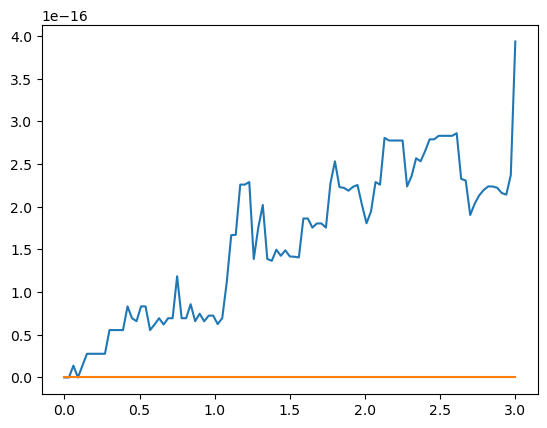

In [37]:
"""
Check c is antisymmetric
"""
def check_c2_antisymmetry(c2):
    bra_error=[]
    ket_error=[]
    for t in range(len(soln.t)):
        bra_error.append(np.max(np.abs(c2[:,:,:,:,t] + c2[:,:,:,:,t].swapaxes(0, 1))))
        ket_error.append(np.max(np.abs(c2[:,:,:,:,t] + c2[:,:,:,:,t].swapaxes(2, 3))))
    return np.array(bra_error), np.array(ket_error)

c4 = c_soln.reshape(2*P, 2*P, 2*P, 2*P, len(soln.t))
bra_err, ket_err = check_c2_antisymmetry(c4)

plt.plot(soln.t,bra_err)
plt.plot(soln.t,ket_err)
plt.show()


(36, 36)


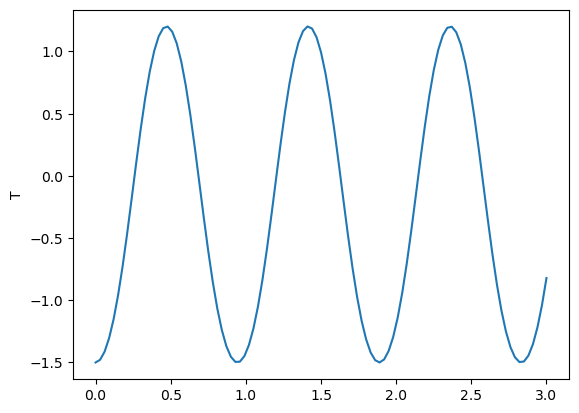

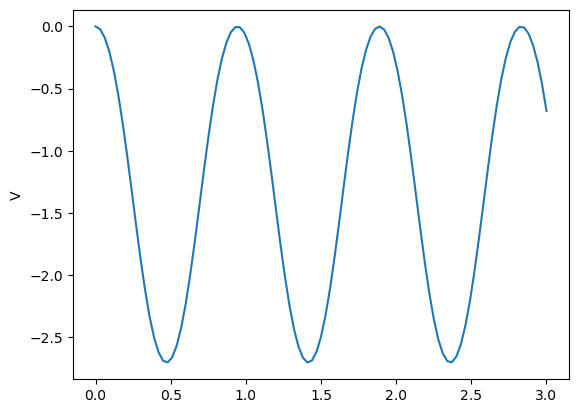

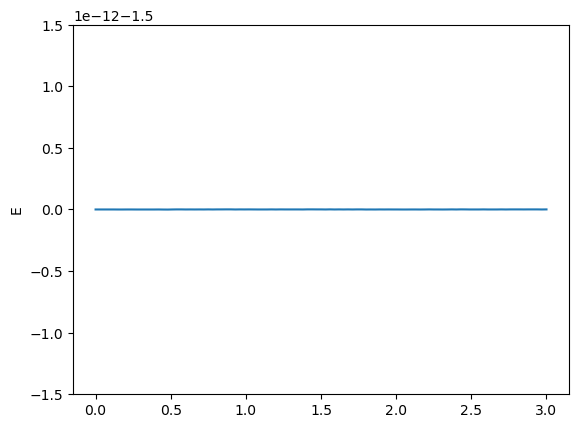

In [38]:
"""
Check energy conservation
"""
# print(h0())
print(v().shape)

# kinetic first (1body)
Ttot = np.trace( np.einsum("ijt,jk->ikt",rho_soln,h0()), axis1=0, axis2=1)
# now potential (2body)
Vtot = 0.5*np.trace( np.einsum("ijt,jk->ikt",rho2_soln,v()), axis1=0, axis2=1)
# print(f'V: {V[0].real:.3f},{V[100].real:.3f},{V[200].real:.3f}')
Etot = Ttot + Vtot

plt.plot(soln.t,Ttot)
plt.ylabel('T')
plt.show()
plt.plot(soln.t,Vtot)
plt.ylabel('V')
plt.show()

plt.plot(soln.t,Etot)
plt.ylabel('E')
plt.show()

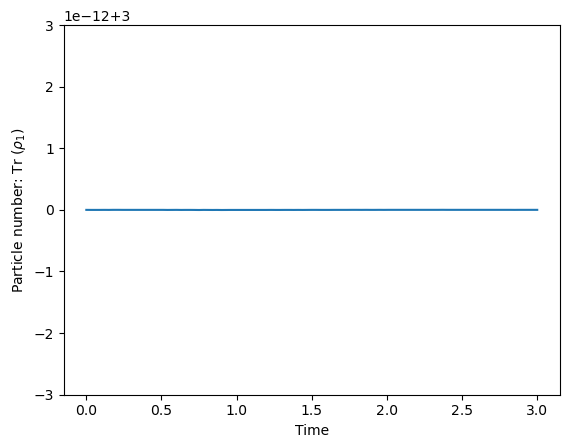

In [39]:
"""
particle number should be conserved
"""

plt.plot(soln.t,np.trace(rho_soln,axis1=0,axis2=1))
# plt.ylim(0,4)
plt.ylabel(r'Particle number: Tr $(\rho_1)$')
plt.xlabel('Time')
plt.show()

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]


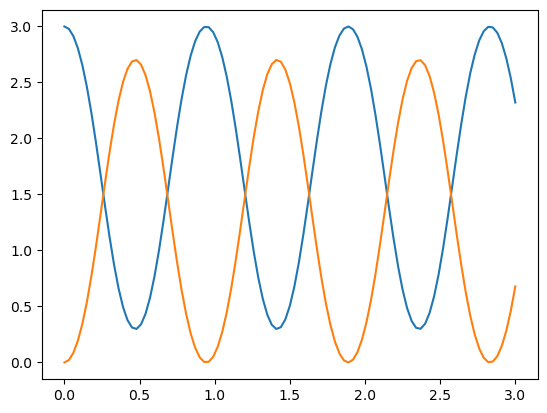

In [42]:
"""
Check number of particles in the bottom 
"""

def Ndown(rho):
    down = np.zeros((2*P,2*P),dtype=complex)
    for i in range(P):
        down[i,i] = 1
    return np.trace(np.einsum("ijt,jk->ikt",rho,down), axis1=0,axis2=1)

def Nup(rho):
    up = np.zeros((2*P,2*P),dtype=complex)
    for i in range(P,2*P):
        up[i,i] = 1
    print(up)
    return np.trace(np.einsum("ijt,jk->ikt",rho,up), axis1=0,axis2=1)

plt.plot(soln.t,Ndown(rho_soln),label='down')
plt.plot(soln.t,Nup(rho_soln),label='up')
plt.show()

In [45]:
# print(c_soln[:,:,0])
# print(c_soln[:,:,50])
# print(c_soln[:,:,-1])
print(np.max(c_soln))

(0.2498934076748357-2.3025849785069253e-18j)


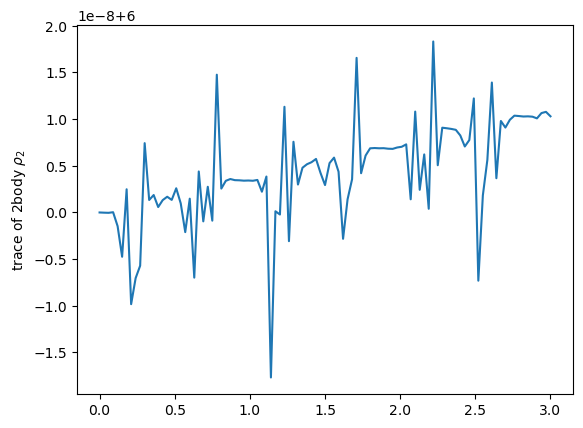

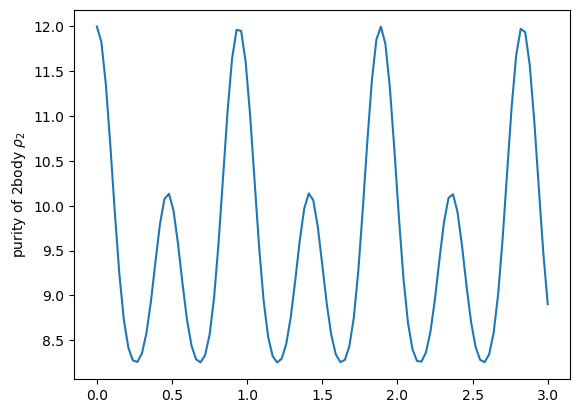

In [47]:
"""
Check purity
"""
# this was purity of 1body rho
# rhosq = np.einsum("ijt,jkt->ikt",rho_soln,rho_soln)
# plt.plot(t_list,np.trace(rhosq, axis1=0,axis2=1))
# plt.show()

# trace of twobody rho
# factor of 4 so that trace of rho12 is 1
plt.plot(soln.t,np.trace(rho2_soln,axis1=0,axis2=1))
plt.ylabel(r'trace of 2body $\rho_2$')
plt.show()

# purity of twobody rho
# factor of 16 so that trace of rho12 is 1 (a factor of 4 each)
plt.plot(soln.t,np.trace(   np.einsum('ijt,jkt->ikt',rho2_soln,rho2_soln)    ,axis1=0,axis2=1))
# plt.ylim(0,10)
plt.ylabel(r'purity of 2body $\rho_2$')
plt.show()

# # trace of twobody correlation
# plt.plot(soln.t,np.trace(c_soln,axis1=0,axis2=1))
# plt.ylabel(r'trace of 2body $c_2$')
# plt.show()

# # purity of correlation part only
# plt.plot(soln.t,np.trace(    np.einsum('ijt,jkt->ikt',c_soln,c_soln)    ,axis1=0,axis2=1))
# # plt.ylim(-1,10)
# plt.ylabel(r'purity of 2body correlation $c_2$')
# plt.show()

In [48]:
"""
Check if the density matrix stays hermitian
It does
"""

dI2 = rho2_soln - rho2_soln.conj().transpose(1,0,2)
print(dI2.real.max())
print(dI2.imag.max())

dI1 = rho_soln - rho_soln.conj().transpose(1,0,2)
print(dI1.real.max())
print(dI1.imag.max())

1.4016565685892601e-15
1.4614710029957088e-15
0.0
1.0192000215544387e-15


## Lipkin exact evolution ##

(216, 216)
(216, 216, 51)


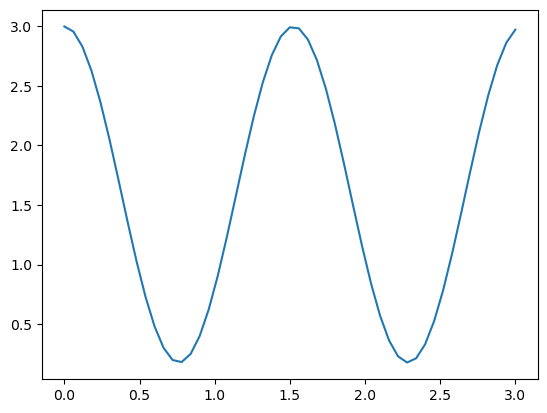

In [25]:
t_list=np.linspace(0.0,3.0,51)

p1 = np.array([1,0,0,0,0,0],dtype=complex)
p2 = np.array([0,1,0,0,0,0],dtype=complex)
p3 = np.array([0,0,1,0,0,0],dtype=complex)
psiin = np.einsum('i,j,k->ijk',p1,p2,p3)
apsiin = ( psiin 
          -np.einsum('ijk->ikj',psiin)
          -np.einsum('ijk->jik',psiin)
          +np.einsum('ijk->jki',psiin)
          +np.einsum('ijk->kij',psiin)
          -np.einsum('ijk->kji',psiin)
         )
Din = np.einsum('ijk,lmn->ijklmn',psiin,psiin.conj() )
Din = Din.reshape(8*P**3,8*P**3)
print(Din.shape)

I2P = np.eye(2*P,dtype=complex)
H = ( np.einsum('il,jm,kn->ijklmn',h0(),I2P,I2P) 
     # +np.einsum('jm,il,kn->ijklmn',h0(),I2P,I2P) 
     # +np.einsum('jm,kn,il->ijklmn',h0(),I2P,I2P) 
     +np.einsum('ijlm,kn->ijklmn',v().reshape(2*P,2*P,2*P,2*P),I2P) 
    )
H = H.reshape(8*P**3,8*P**3)
Dout = []
for t in t_list:
    Dout.append( expm(-1j*H*t) @ Din @ expm(1j*H*t) )
    # print(( expm(-1j*H*t) @ Din @ expm(1j*H*t) ).shape)
Dout = np.array(Dout)
Dout = np.moveaxis(Dout,0,-1)
print(Dout.shape)

"""
Check number of particles in the bottom 
"""
rho1_exact = 3*np.einsum( 'ijkljkt->ilt', Dout.reshape(2*P,2*P,2*P,2*P,2*P,2*P,len(t_list)) )
plt.plot(t_list,Ndown(rho1_exact),label='down')

## TDHF calc ##

In [9]:
"""
Initial conditions
"""

# rho0 = np.array([
#     [1, 0, 0, 0, 0, 0],
#     [0, 1, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 1, 0, 0],
#     [0, 0, 0, 0, 0, 0],
#     [0, 0, 0, 0, 0, 0]
# ], dtype=complex)
""" If rho0 is diagonal then we get a stationary solution of TDHF!!! """
rho0 = np.array([
    [0.5, 0.0, 0.0, 0.0, 0.0, 0.5],
    [0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.0, 0.0, 0.0, 0.5]
], dtype=complex)

y0 = rho0.ravel()

"""
Consistency checks for integration

'assert' continues on if answer is True, or raises error if False
""" 
assert rho0.shape == (2*P,2*P)
# assert c20.shape == (4,4)
assert y0.shape == (4*P**2,)

# Evaluate the RHS once to catch indexing errors.
test_derivative = TDHF(t=0.0,y=y0)
assert test_derivative.shape == y0.shape
assert np.all(np.isfinite(test_derivative))

print('P =',P)
print("Initial state shape:", y0.shape)
print("Initial derivative shape:", test_derivative.shape)

P = 3
Initial state shape: (36,)
Initial derivative shape: (36,)


In [10]:
"""
And now we integrate
"""

t_list = np.linspace(0.0,10.0,501)
soln_tdhf = solve_ivp( 
    fun=TDHF,
    t_span = (t_list[0],t_list[-1]), 
    y0 = y0,
    t_eval = t_list,
    method = "RK45", # BDF  DOP853
    rtol=1e-9,
    atol=1e-11,
)

if not soln_tdhf.success:
    raise RuntimeError(
        f"Integration failed: {soln_tdhf.message}"
    )

In [13]:
rho_soln_tdhf = soln_tdhf.y.reshape(2*P,2*P,len(soln_tdhf.t))
rhorho_soln_tdhf = ( np.einsum("abt,cdt->acbdt", rho_soln_tdhf, rho_soln_tdhf)
                    - np.einsum("abt,cdt->acdbt", rho_soln_tdhf, rho_soln_tdhf) )
rhorho_soln_tdhf = rhorho_soln_tdhf.reshape(4*P**2,4*P**2,len(soln_tdhf.t))

print("rho_solution shape:", rho_soln_tdhf.shape)
print("rhorho_solution shape:", rhorho_soln_tdhf.shape)

rho_solution shape: (6, 6, 501)
rhorho_solution shape: (36, 36, 501)


(36, 36)


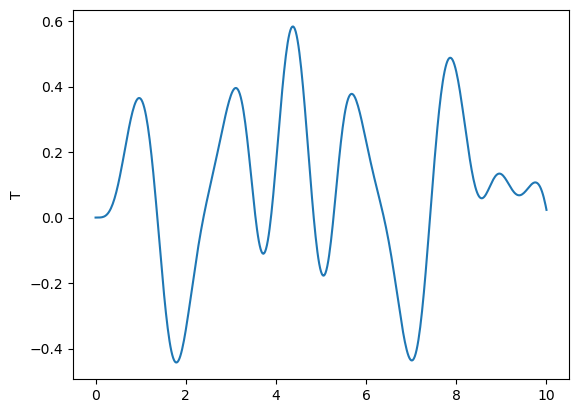

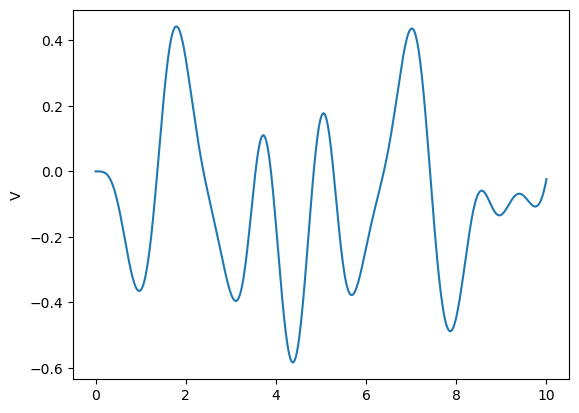

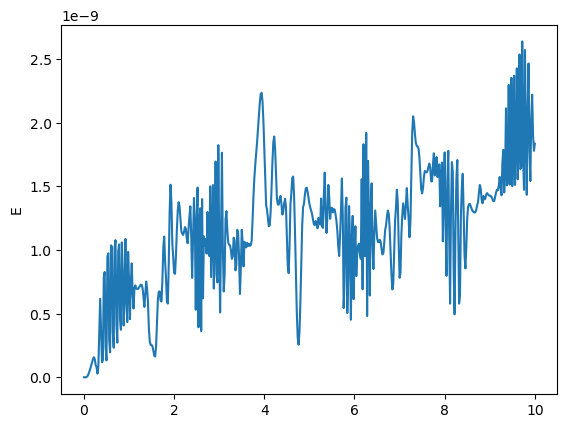

In [14]:
"""
Check energy conservation
"""
# print(h0())
print(v().shape)

# kinetic first (1body)
Ttot = np.trace( np.einsum("ijt,jk->ikt",rho_soln_tdhf,h0()), axis1=0, axis2=1)
# now potential (2body)
Vtot = 0.5*np.trace( np.einsum("ijt,jk->ikt",rhorho_soln_tdhf,v()), axis1=0, axis2=1)
# print(f'V: {V[0].real:.3f},{V[100].real:.3f},{V[200].real:.3f}')
Etot = Ttot + Vtot

plt.plot(soln_tdhf.t,Ttot)
plt.ylabel('T')
plt.show()
plt.plot(soln_tdhf.t,Vtot)
plt.ylabel('V')
plt.show()

plt.plot(soln_tdhf.t,Etot)
plt.ylabel('E')
plt.show()

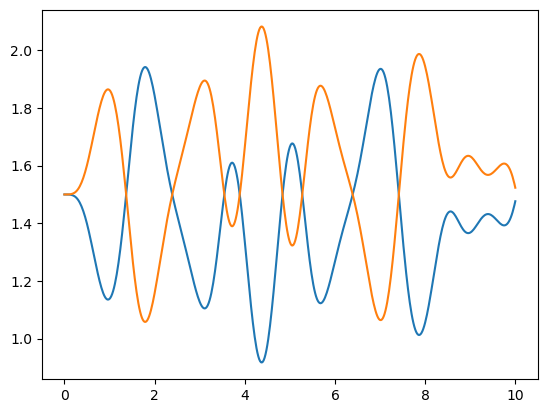

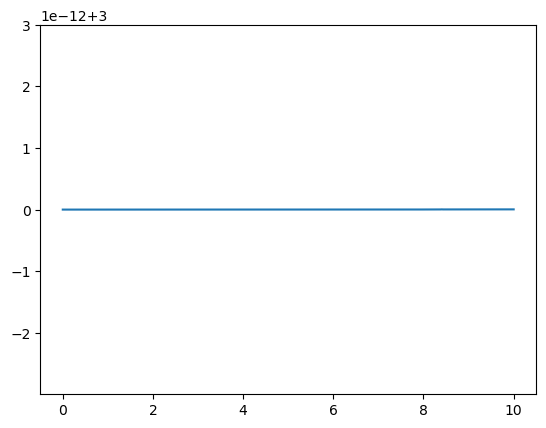

In [17]:
"""
Check number of particles in the bottom 
"""

def Ndown(rho):
    down = np.zeros((2*P,2*P),dtype=complex)
    for i in range(P):
        down[i,i] = 1
    return np.trace(np.einsum("ijt,jk->ikt",rho,down), axis1=0,axis2=1)

def Nup(rho):
    up = np.zeros((2*P,2*P),dtype=complex)
    for i in range(P,2*P):
        up[i,i] = 1
    return np.trace(np.einsum("ijt,jk->ikt",rho,up), axis1=0,axis2=1)


plt.plot(soln_tdhf.t,Ndown(rho_soln_tdhf))
plt.plot(soln_tdhf.t,Nup(rho_soln_tdhf))
plt.show()

plt.plot(soln_tdhf.t,Ndown(rho_soln_tdhf)+Nup(rho_soln_tdhf))
plt.show()

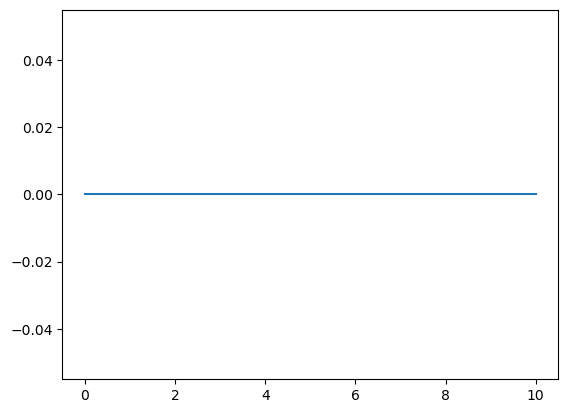

In [8]:
"""
check tdhf property rho^2 = rho
"""

def idempotency_error(rho):
    max = []
    for t in range(len(soln_tdhf.t)):
        max.append(np.max(np.abs(rho[:,:,t] @ rho[:,:,t] - rho[:,:,t])))
    return np.array(max)
plt.plot(soln_tdhf.t,idempotency_error(rho_soln_tdhf))

In [70]:
# print(c2_soln[:,:,0])
# print(c2_soln[:,:,200])
# print(c2_soln[:,:,-1])
# print(np.max(c2_soln))

## exact toy model 3 particles ##

H (8, 8)
501
(2, 2, 2, 2, 2, 2, 501)
rho12 (2, 2, 2, 2, 501)
(2, 2, 501)


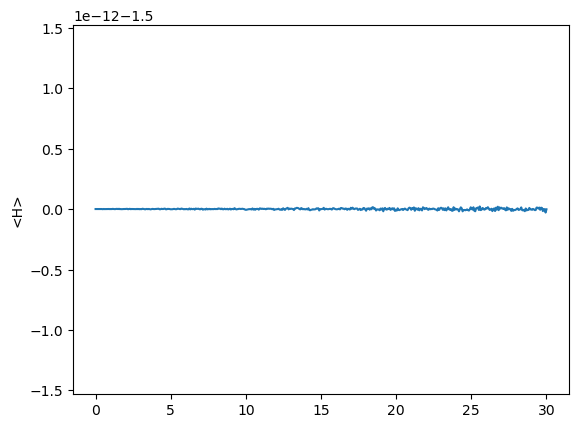

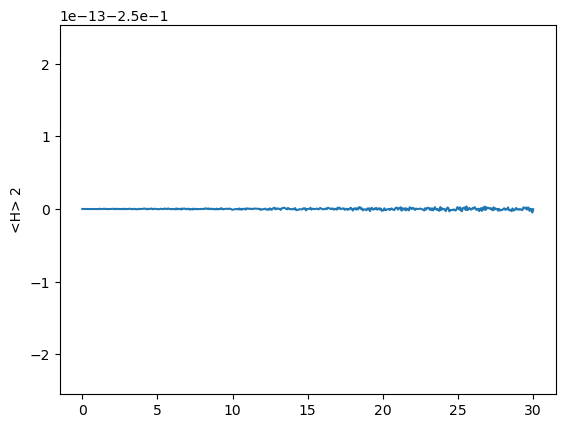

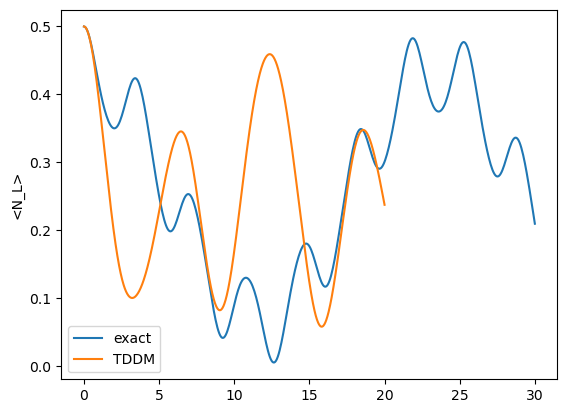

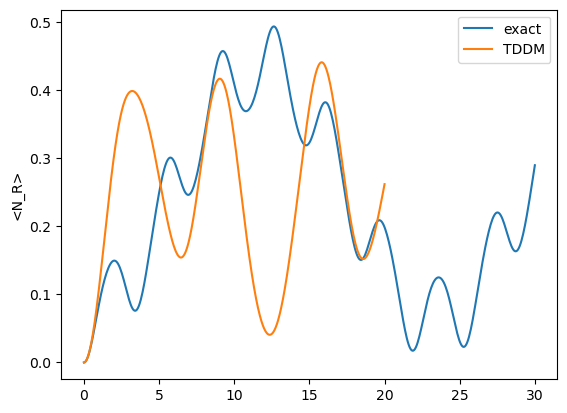

In [333]:
# set up the system and hamiltonian 
# mu = -0.8

h0 = a/2*np.array([[1,-1],
                   [-1,1]],dtype=complex)
v = np.array([[mu,0,0,0],
              [0,0,0,0],
              [0,0,0,0],
              [0,0,0,mu]],dtype=complex)
I2 = np.eye(2,dtype=complex)
P23 = np.array([[1, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 1, 0, 0, 0, 0, 0],
                [0, 1, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 1, 0, 0, 0, 0],
                [0, 0, 0, 0, 1, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 1, 0],
                [0, 0, 0, 0, 0, 1, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 1]], dtype=complex)
T = np.kron(np.kron(h0,I2),I2) + np.kron(np.kron(I2,h0),I2) + np.kron(np.kron(I2,I2),h0)
V = np.kron(v,I2) + P23@np.kron(v,I2)@P23.T.conj() + np.kron(I2,v)
H = T+V
print('H',H.shape)

# set up the state evolution
def rhoout(t_list,psiin):
    rhoout=[]
    for t in t_list:
        psiout = expm(-1j*H*t)@psiin
        rho = np.outer(psiout.T.conj(),psiout)
        rho = rho.reshape(2,2,2,2,2,2)
        rhoout.append(rho)
    rhoout = np.array(rhoout,dtype=complex)
    rhoout = np.moveaxis(rhoout, 0, -1)
    return rhoout

# calculate the state evolution
L1 = np.array([1,0],dtype=complex)
psiin = np.kron(np.kron(L1,L1),L1)
t_list = np.linspace(0.0,30.0,501)
print(len(t_list))
rhoout_exact = rhoout(t_list,psiin)
print(rhoout_exact.shape)

# make reduced density matrices
rho12_exact = (1)*np.trace(rhoout_exact,axis1=2,axis2=5) # coefficient depends on convention, 6 or 1
print('rho12',rho12_exact.shape)
rho1_exact = (1/2)*np.trace(   np.trace(rhoout_exact,axis1=2,axis2=5)   ,axis1=1,axis2=3) # coefficient depends on convention, 6/2 or 1/2
print(rho1_exact.shape)


# Look at energy conservation
# first using full rho and full H
rhoout_8x8 = rhoout_exact.reshape(8,8,len(t_list))
exE = np.trace( np.einsum('ijt,jk->ikt',rhoout_8x8,H) , axis1=0, axis2=1)
plt.plot(t_list,exE)
plt.ylabel('<H>')
plt.show()

# now using reduced densities and 1body, 2body components of H
exE2 = np.trace( np.einsum('ijt,jk->ikt',rho1_exact,h0) , axis1=0, axis2=1) + 0.5*np.trace( np.einsum('ijt,jk->ikt',rho12_exact.reshape(4,4,len(t_list)),v) , axis1=0, axis2=1)
plt.plot(t_list,exE2)
plt.ylabel('<H> 2')
plt.show()
# CLEARLY NEED THE FACTOR OF 0.5 INFRONT OF 2BODY V TERM SO THAT GET THE SAME E AND ALSO SO THAT E IS CONSERVED 



# Now look at number of particles in each well
plt.plot(t_list,NL(rho1_exact),label='exact')
plt.plot(soln.t,NL(rho_soln),label='TDDM')
plt.ylabel('<N_L>')
# plt.ylim(-0.5,3.5)
plt.legend()
plt.show()

plt.plot(t_list,NR(rho1_exact),label='exact')
plt.plot(soln.t,NR(rho_soln),label='TDDM')
plt.ylabel('<N_R>')
# plt.ylim(-0.5,3.5)
plt.legend()
plt.show()


# testing some properties of the 2body density, to inform code above. 
# first, the trace stays at 6:
    # plt.plot(t_list,np.trace(rho12_exact.reshape(4,4,len(t_list)),axis1=0,axis2=1))
    # plt.show()
# the norm starts at 6 but is not conserved, thats fine 
    # plt.plot(t_list,np.linalg.norm(rho12_exact.reshape(4,4,len(t_list)),axis=(0,1)))
    # plt.show()

# the 1body density trace stays at 3 as expected (particle number) 
    # plt.plot(t_list,np.trace(rho1_exact,axis1=0,axis2=1))
    # plt.show()